In [1]:
from __future__ import print_function, division
import os
import torch
import pandas as pd
from skimage import io, transform
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils, datasets, models
import SimpleITK as sitk
from PIL import Image
import torchvision
import glob
import random
import time
import cv2
import  torch.nn as nn
import torch.nn.functional as F 
import PIL


# Ignore warnings
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["CUDA_VISIBLE_DEVICES"]="1"

In [2]:
import loader_outdoor

In [3]:
Radio_train = loader_outdoor.RadioUNet_3d(phase="train")
Radio_val = loader_outdoor.RadioUNet_3d(phase="val")
Radio_test = loader_outdoor.RadioUNet_3d(phase="test")

image_datasets = {
    'train': Radio_train, 'val': Radio_val
}

batch_size = 8
# num of samples to decide direction of learning decrease

dataloaders = {
    'train': DataLoader(Radio_train, batch_size=batch_size, shuffle=True, num_workers=1),
    'val': DataLoader(Radio_val, batch_size=batch_size, shuffle=True, num_workers=1)
}


phase train
phase val
phase test
__len__ 40000
__len__ 40000
__len__ 8000
__len__ 8000


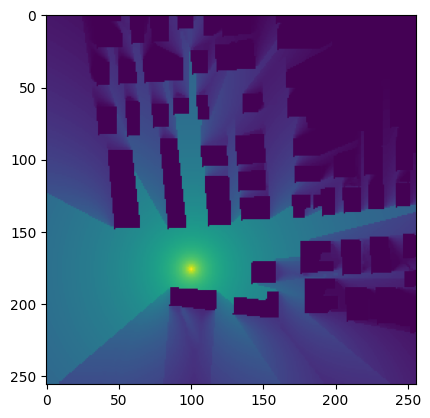

In [4]:
i=10
image_build_ant, image_gain= Radio_train[i]
plt.imshow(image_gain[0])

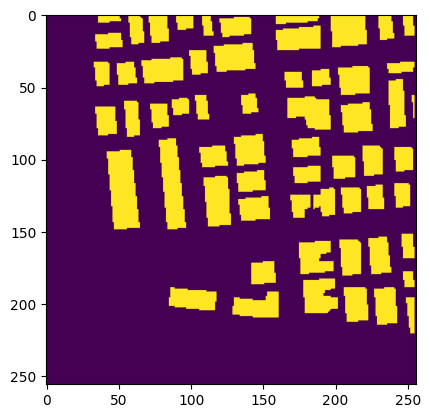

In [5]:
plt.imshow(image_build_ant[0])

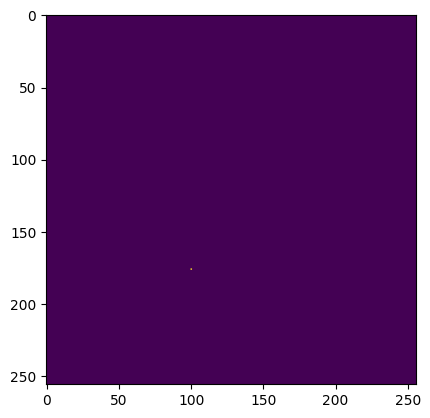

In [6]:
plt.imshow(image_build_ant[1])

In [7]:
def conv2dreluM(in_channels, out_channels, kernel, padding, pool):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel, padding=padding),
        nn.BatchNorm2d(out_channels, eps=1e-5, momentum=1 - 0.999),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(pool, stride=pool, padding=0, dilation=1, return_indices=False, ceil_mode=False) 
    )
def convbat(in_channels, out_channels, kernel, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel, padding=padding),
        nn.BatchNorm2d(out_channels, eps=1e-5, momentum=1 - 0.999)
    )
def conv2d(in_channels, out_channels, kernel, padding, pool):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel, padding=padding),
        nn.BatchNorm2d(out_channels, eps=1e-5, momentum=1 - 0.999),
        nn.ReLU(inplace=True)
    )

In [8]:
def convreluT(in_channels, out_channels, kernel, padding):
    return nn.Sequential(
        nn.ConvTranspose2d(in_channels, out_channels, kernel, stride=2, padding=padding),
        nn.ReLU(inplace=True)
    )

In [9]:
import torch.nn.functional as F
class _Bottleneck(nn.Module):

    def __init__(self, in_channels, out_channels,downsample):
        super(_Bottleneck, self).__init__()
        mid_ch = out_channels // 4
        self.reduce = conv2dreluM(in_channels, mid_ch, 1, 0, 1)
        self.conv3x3 = conv2dreluM(mid_ch, mid_ch, 3, 1, 1)
        self.increase = convbat(mid_ch, out_channels, 1, 0)
        self.shortcut = (
            nn.Conv2d(in_channels, out_channels, 1, 1)
            if downsample
            else nn.Identity()
        )

    def forward(self, x):
        h = self.reduce(x)
        h = self.conv3x3(h)
        h = self.increase(h)
        h += self.shortcut(x)
        return F.relu(h)

In [10]:
def dilat_conv2drelu(in_channels, out_channels, kernel, padding, dilation):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel, padding=padding, dilation=dilation),
        nn.BatchNorm2d(out_channels, eps=1e-5, momentum=1 - 0.999),
        nn.ReLU(inplace=True) 
    )

In [11]:
import torch.nn.functional as F
class dilat_Bottleneck(nn.Module):

    def __init__(self, in_channels, out_channels,dilation,downsample):
        super(dilat_Bottleneck, self).__init__()
        mid_ch = out_channels // 4
        self.reduce = conv2dreluM(in_channels, mid_ch, 1, 0, 1)
        self.conv3x3 = dilat_conv2drelu(mid_ch, mid_ch, 3, 1, 1)
        self.increase = convbat(mid_ch, out_channels, 1, 0)
        self.shortcut = (
            nn.Conv2d(in_channels, out_channels, 1, 1)
            if downsample
            else nn.Identity()
        )

    def forward(self, x):
        h = self.reduce(x)
        h = self.conv3x3(h)
        h = self.increase(h)
        h += self.shortcut(x)
        return F.relu(h)

In [12]:
def conv2dMdrop(in_channels, out_channels, kernel, padding, pool, drop):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel, padding=padding),
        nn.BatchNorm2d(out_channels, eps=1e-5, momentum=1 - 0.999),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(pool, stride=pool, padding=0, dilation=1, return_indices=False, ceil_mode=False), 
        nn.Dropout(drop)
    )
def conv2ddrop(in_channels, out_channels, kernel, padding, pool, drop):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel, padding=padding),
        nn.BatchNorm2d(out_channels, eps=1e-5, momentum=1 - 0.999),
        nn.ReLU(inplace=True), 
        nn.Dropout(drop)
    )

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, in_channel=2, out_channel=1):
        super(UNet, self).__init__()
        self.layer1 = conv2d(in_channel, 6, 3, 1,1) 
        self.layer2 = conv2dreluM(6, 40, 5, 2,2)
        
        self.layer3 = conv2dreluM(40, 60, 5, 2,2)  
        self.layer4 = _Bottleneck(60, 60, downsample=True)
        self.layer40 = _Bottleneck(60, 60, downsample=False)
        self.layer400 = _Bottleneck(60, 60, downsample=False)
        
        self.layer5 = conv2dreluM(60, 100, 5, 2,2) 
        self.layer6 = _Bottleneck(100, 100, downsample=True)
        self.layer60 = _Bottleneck(100, 100, downsample=False)
        self.layer600 = _Bottleneck(100, 100, downsample=False)
        
        self.layer7 = conv2dMdrop(100, 150, 5, 2,2,0.3) 
        
        self.layer70 = _Bottleneck(150, 150, downsample=True)
        self.layer700 = _Bottleneck(150, 150, downsample=False)
        self.layer7000 = _Bottleneck(150, 150, downsample=False)
        
        self.layer71=dilat_Bottleneck(150, 150,2,downsample=True)
        self.layer710=dilat_Bottleneck(150, 150,4,downsample=False)
        self.layer7100=dilat_Bottleneck(150, 150,8,downsample=False)
        
        self.layer72=conv2dreluM(150, 37, 1, 0, 1)
        self.layer720=dilat_conv2drelu(150, 37, 3, padding=6, dilation=6)
        self.layer7200=dilat_conv2drelu(150, 37, 3, padding=12, dilation=12)
        self.layer72000=dilat_conv2drelu(150, 37, 3, padding=18, dilation=18)
        
        self.layer73=nn.AdaptiveAvgPool2d(1)
        self.layer730=conv2dreluM(150, 37, 1, 0, 1)
        
        self.layer8 = conv2dMdrop(150+35, 300, 5, 2,2,0.3) 
        
        self.conv_up2 = conv2ddrop(300, 150, 3, 1, 1,0.3) 
        self.conv_up3 = convreluT(150 + 150, 100, 4, 1) 
        self.conv_up4 = conv2d(100 + 100, 100, 3, 1, 1) 
        self.conv_up5 = convreluT(100 + 100, 60, 6, 2) 
        self.conv_up6 = conv2d(60 + 60, 60, 5, 2, 1) 
        self.conv_up7 = convreluT(60 + 60, 40, 6, 2)
        self.conv_up8 = convreluT(40 + 40, 20, 6, 2) 
        
        self.conv_up9 = conv2d(20 + 6+in_channel, 20, 5, 2, 1)
        self.conv_up10 = conv2d(20 + in_channel, out_channel, 5, 2, 1)


    def forward(self, input0):

        layer1 = self.layer1(input0) 
        layer2 = self.layer2(layer1) 
        layer3 = self.layer3(layer2) 
        layer4 = self.layer4(layer3) 
        layer40 = self.layer40(layer4) 
        layer400 = self.layer400(layer40)
        layer5 = self.layer5(layer400) 
        layer6 = self.layer6(layer5) 
        layer60 = self.layer60(layer6)
        layer600 = self.layer600(layer60)
        layer7 = self.layer7(layer600) 
        layer70 = self.layer70(layer7)
        layer700 = self.layer700(layer70)
        layer7000 = self.layer7000(layer700)
        
        layer71 = self.layer71(layer7000)
        layer710 = self.layer710(layer71)
        layer7100 = self.layer7100(layer710)
        
        layer72 = self.layer72(layer7100)
        layer720 = self.layer720(layer7100)
        layer7200 = self.layer7200(layer7100)
        layer72000 = self.layer72000(layer7100)
        
        layer73 = self.layer73(layer7100)
        layer730 = self.layer730(layer73)
        layer7300 = F.interpolate(layer730, size=(16, 16), mode="bilinear", align_corners=False)
        
        layer74=torch.cat([layer72,layer720,layer7200,layer72000,layer7300], dim=1)#185,16,16
        
        layer8 = self.layer8(layer74) 
        
        Up = nn.Upsample(scale_factor=2,mode='nearest')
        
        layer20u = Up(layer8)
        layer21u = self.conv_up2(layer20u) 
        layer2u = torch.cat([layer21u, layer7000], dim=1) 
        
        layer30u = self.conv_up3(layer2u) 
        layer3u = torch.cat([layer30u, layer600], dim=1) 
        
        layer40u = self.conv_up4(layer3u)
        layer4u =  torch.cat([layer40u, layer5], dim=1)  
        
        layer50u = self.conv_up5(layer4u) 
        layer5u = torch.cat([layer50u, layer400], dim=1) 
        
        layer60u = self.conv_up6(layer5u) 
        layer6u = torch.cat([layer60u, layer3], dim=1) 
        
        layer70u = self.conv_up7(layer6u)
        layer7u = torch.cat([layer70u, layer2], dim=1) 
        
        layer80u = self.conv_up8(layer7u) 
        layer81u = torch.cat([layer80u, layer1], dim=1) 
        layer8u = torch.cat([layer81u, input0], dim=1) 
        
        layer90u = self.conv_up9(layer8u) 
        layer9u = torch.cat([layer90u, input0], dim=1) 
        output = self.conv_up10(layer9u) 

        return output


In [ ]:
from torchsummary import summary

device = torch.device("cpu")
print(device)
torch.set_default_dtype(torch.float32)
torch.backends.cudnn.enabled
model =UNet(in_channel=2, out_channel=1)
model.to(device)

summary(model, input_size=(2,256,256),device='cpu')


In [14]:
from torchsummary import summary

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)

torch.backends.cudnn.enabled
model =UNet(in_channel=2, out_channel=1)
model.cuda()

summary(model, input_size=(2,256,256),device='cuda')

cuda:1
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 6, 256, 256]             114
       BatchNorm2d-2          [-1, 6, 256, 256]              12
              ReLU-3          [-1, 6, 256, 256]               0
            Conv2d-4         [-1, 40, 256, 256]           6,040
       BatchNorm2d-5         [-1, 40, 256, 256]              80
              ReLU-6         [-1, 40, 256, 256]               0
         MaxPool2d-7         [-1, 40, 128, 128]               0
            Conv2d-8         [-1, 60, 128, 128]          60,060
       BatchNorm2d-9         [-1, 60, 128, 128]             120
             ReLU-10         [-1, 60, 128, 128]               0
        MaxPool2d-11           [-1, 60, 64, 64]               0
           Conv2d-12           [-1, 15, 64, 64]             915
      BatchNorm2d-13           [-1, 15, 64, 64]              30
             ReLU-14           [

structure

## Training Loop

In [ ]:
#Adapted from https://github.com/RonLevie/RadioUNet

import torch
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy
from collections import defaultdict
import torch.nn.functional as F
import torch.nn as nn

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

def calc_loss_dense(pred, target, metrics):
    criterion = nn.MSELoss()
    loss = criterion(pred, target)
    metrics['loss'] += loss.data.cpu().numpy() * target.size(0)

    return loss

def print_metrics(metrics, epoch_samples, phase):
    outputs1 = []
    outputs2 = []
    for k in metrics.keys():
        outputs1.append("{}: {:4f}".format(k, metrics[k] / epoch_samples))

    print("{}: {}".format(phase, ", ".join(outputs1)))

def train_model(model, optimizer, scheduler, num_epochs=50):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 1e10
    best_num=0

    for epoch in range(num_epochs):
        # just go num_epochs times
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        since = time.time()

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                scheduler.step()
                for param_group in optimizer.param_groups:
                    print("learning rate", param_group['lr'])

                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            metrics = defaultdict(float)
            epoch_samples = 0

            
            for inputs, targets in dataloaders[phase]:
                inputs = inputs.cuda()
                targets = targets.cuda()
                #inputs = inputs.to(device)
                #targets = targets.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs1 = model(inputs)
                    loss = calc_loss_dense(outputs1, targets, metrics)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                epoch_samples += inputs.size(0)
                    

            print_metrics(metrics, epoch_samples, phase)
            epoch_loss = metrics['loss'] / epoch_samples

            # deep copy the model
            if phase == 'val' and epoch_loss < best_loss:
                print("saving best model")
                best_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), '/R2Net-Outlite_best_v'+str(best_num)+'.pt')
                best_num=best_num+1

        time_elapsed = time.time() - since
        print('{:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
        torch.save(model.state_dict(), '/R2Net-Outlite_v'+str(epoch)+'.pt')

    print('Best val loss: {:4f}'.format(best_loss))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

In [ ]:
import torch
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)


optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=30, gamma=0.1)

model = train_model(model, optimizer_ft, exp_lr_scheduler)

In [ ]:
model.load_state_dict(torch.load('/R2Net-Outlite.pt',map_location=torch.device('cpu')))
model.to(device)

In [15]:
model.load_state_dict(torch.load('/R2Net-Outlite.pt'))
model.cuda()

UNet(
  (layer1): Sequential(
    (0): Conv2d(2, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.0010000000000000009, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer2): Sequential(
    (0): Conv2d(6, 40, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(40, eps=1e-05, momentum=0.0010000000000000009, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Conv2d(40, 60, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(60, eps=1e-05, momentum=0.0010000000000000009, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer4): _Bottleneck(
    (reduce): Sequential(
      (0): Conv2d(60, 15, kernel_size=(1, 1), stride=(1, 1))
    

In [16]:
import math
import torch
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy
from collections import defaultdict
import torch.nn.functional as F
import torch.nn as nn

import math
from torchmetrics.image import StructuralSimilarityIndexMeasure

def cul_psnr(original, reconstructed, max_pixel=1.0):
    mse_psnr1 = F.mse_loss(original, reconstructed)  
    if mse_psnr1 == 0:
        return float('inf')  
    psnr_value = 10 * torch.log10(max_pixel ** 2 / mse_psnr1)
    return psnr_value.item()

def rmse_ssim_psnr(pred1_gpu, target_gpu):
    
    crit_ssim = StructuralSimilarityIndexMeasure(data_range=1.0).cuda() # for gpu
    #crit_ssim = StructuralSimilarityIndexMeasure(data_range=1.0) # for cpu 
    ssim =crit_ssim(pred1_gpu, target_gpu)
    
    psnr = cul_psnr(target_gpu,pred1_gpu)
    MSE = torch.mean((pred1_gpu-target_gpu)**2)
    NMSE = torch.mean((pred1_gpu-target_gpu)**2)/torch.mean(target_gpu**2)
    
    
    return ssim, psnr,NMSE,MSE

def calc_loss_test(pred1, target, metrics, error="MSE"):
    criterion = nn.MSELoss()
    if error=="MSE":
        loss1 = criterion(pred1, target)
    else:
        loss1 = criterion(pred1, target)/criterion(target, 0*target)
    metrics['loss first U'] += loss1.data.cpu().numpy() * target.size(0)
    return loss1

def print_metrics_test(metrics, epoch_samples, error):
    outputs = []
    for k in metrics.keys():
        outputs.append("{}: {:4f}".format(k, metrics[k] / epoch_samples))
    print("{}: {}".format("Test"+" "+error, ", ".join(outputs)))

def test_loss(model, error="MSE", dataset="coarse"):
    # dataset is "coarse" or "fine".
    since = time.time()
    model.eval()   # Set model to evaluate mode
    metrics = defaultdict(float)
    epoch_samples = 0
    
    ssim_all=0
    psnr_all=0
    NMSE_all=0
    MSE_all=0
    num_test_sample=0
    loss_all1=np.zeros([8080])
    for inputs, targets in DataLoader(Radio_test, batch_size=1, shuffle=True, num_workers=1):
        #inputs = inputs.to(device) # for cpu
        #targets = targets.to(device)
        inputs = inputs.cuda() # for gpu
        targets = targets.cuda()
        # do not track history if only in train
        with torch.set_grad_enabled(False):
            outputs1= model(inputs)
            loss1= calc_loss_test(outputs1, targets, metrics, error)
            loss_all1[num_test_sample]=loss1
                
            ssim, psnr,NMSE,MSE=rmse_ssim_psnr(outputs1, targets)
            ssim_all=ssim_all+ssim
            psnr_all=psnr_all+psnr
            NMSE_all=NMSE_all+NMSE
            MSE_all=MSE_all+MSE
                
            num_test_sample=num_test_sample+1
            epoch_samples += inputs.size(0)
    print_metrics_test(metrics, epoch_samples, error)
    print('epoch_samples:')
    print(epoch_samples)
    print('all this is epoch_samples')
    time_elapsed = time.time() - since
    print('{:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    return outputs1,targets,loss_all1,ssim_all,psnr_all,NMSE_all,MSE_all

In [17]:
outputs1,targets,loss_all1,ssim_all,psnr_all,NMSE_all,MSE_all=test_loss(model,error="NMSE")#test-0226

__len__ 8080
__len__ 8080
__len__ 8080
__len__ 8080
__len__ 8080
Test NMSE: loss first U: 0.005884
epoch_samples:
8080
all this is epoch_samples
1m 31s


In [18]:
epoch_samples=8080
print('NMSE:',NMSE_all/epoch_samples) 
print('RMSE:',torch.sqrt(MSE_all/epoch_samples)) 
print('SSIM:',ssim_all/epoch_samples) 
print('PSNR:',psnr_all/epoch_samples) 

NMSE: tensor(0.0059, device='cuda:0')
RMSE: tensor(0.0178, device='cuda:0')
SSIM: tensor(0.9420, device='cuda:0')
PSNR: 35.92397002984982
